# Reverse-direction analysis: Can market variables predict subsequent social and news activity?

This notebook examines whether market variables explain subsequent social-media
and news activity for semiconductor stocks.
The analysis is motivated by weak results obtained when using sentiment and
activity features to predict future market behavior.
Only XGBoost is used because it is robust to nonlinear relationships and does
not require assumptions about multicollinearity among predictors.

## 1. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="ticks", font_scale=1.1)

company_colors = {
    "NVDA": "#4DB6AC",
    "AMD": "#BA68C8",
    "INTC": "#5C9BD5"
}

In [2]:
df = pd.read_csv("datasets/final/initial_processed_dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["company", "date"]).reset_index(drop=True)

print(f"Shape    : {df.shape}")
print(f"Period   : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Companies: {df['company'].unique().tolist()}")

Shape    : (7413, 57)
Period   : 2016-05-31 to 2026-03-27
Companies: ['AMD', 'INTC', 'NVDA']


## 2. Define social and news variables

The following variables represent social-media and news response:

 - Reddit post activity
 - Reddit comment activity
 - News coverage
 - Reddit sentiment
 - News sentiment

 The goal is to predict their next-day values using only market-related variables.

In [3]:
SENTIMENT_COLS = [
    "reddit_sentiment",
    "news_sentiment"
]

ACTIVITY_COLS = [
    "reddit_post_count",
    "reddit_comment_count",
    "news_count"
]

SOCIAL_NEWS_COLS = SENTIMENT_COLS + ACTIVITY_COLS

BASE_REVERSE_TARGETS = SOCIAL_NEWS_COLS.copy()


print("Available social/news variables:")
print(BASE_REVERSE_TARGETS)

Available social/news variables:
['reddit_sentiment', 'news_sentiment', 'reddit_post_count', 'reddit_comment_count', 'news_count']


## 3. Create next-day social/news targets

For each company separately, the social/news variables are shifted backward by
one day. This creates targets of the form:

 **market variables at day t → social/news variable at day t+1**

In [4]:
NEXT_DAY_TARGETS = []

for col in BASE_REVERSE_TARGETS:
    next_col = f"{col}_next_day"
    df[next_col] = df.groupby("company")[col].shift(-1)
    NEXT_DAY_TARGETS.append(next_col)

print("Next-day target variables:")
print(NEXT_DAY_TARGETS)

Next-day target variables:
['reddit_sentiment_next_day', 'news_sentiment_next_day', 'reddit_post_count_next_day', 'reddit_comment_count_next_day', 'news_count_next_day']


## 4. Define market predictors

Social/news variables and previously constructed prediction targets are removed
 from the feature set to avoid leakage.

In [5]:
META_COLS = ["date"]

CREATED_TARGET_COLS = [
    "target_direction",
    "target_log_volatility_5d",
]

cols_to_exclude = (
    META_COLS
    + SOCIAL_NEWS_COLS
    + NEXT_DAY_TARGETS
    + CREATED_TARGET_COLS
)

market_feature_cols = [
    col for col in df.columns
    if col not in cols_to_exclude
]

market_feature_cols = list(dict.fromkeys(market_feature_cols))

print(f"Number of market predictors: {len(market_feature_cols)}")
print("\nMarket predictors:")
print(market_feature_cols)

Number of market predictors: 49

Market predictors:
['company', 'open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_20', 'wma_10', 'rsi_14', 'macd', 'macd_signal', 'stoch_k', 'stoch_d', 'williams_r', 'roc_10', 'mom_10', 'trix', 'bb_upper', 'bb_middle', 'bb_lower', 'atr_14', 'natr', 'obv', 'ad', 'adosc', 'log_volume', 'volume_chng', 'rv_daily', 'rv_weekly', 'rv_monthly', 'FEDFUNDS', 'DGS10', 'DGS2', 'yield_spread', 'VIX', 'nasdaq_return', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


## 5. Dataset split

A temporal train/test split is used. The first 80% of observations are used for
training, while the final 20% are used for testing.

In [6]:
split_date = df["date"].quantile(1 - TEST_SIZE)

print(f"Split date: {split_date.date()}")

Split date: 2024-04-08


## 6. Preprocessing and XGBoost model

XGBoost is used because it can capture nonlinear relationships and interactions
between market variables. Since tree-based models are not sensitive to feature
scaling, numeric variables are only imputed and not standardized.

In [7]:
def build_xgb_preprocessor(feature_cols):

    categorical_cols = [c for c in ["company"] if c in feature_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_cols),
            (
                "cat",
                OneHotEncoder(
                    drop="first",
                    sparse_output=False,
                    handle_unknown="ignore"
                ),
                categorical_cols
            )
        ]
    )

In [8]:
xgb_pipeline = Pipeline([
    ("prep", build_xgb_preprocessor(market_feature_cols)),
    ("model", XGBRegressor(
        random_state=RANDOM_STATE,
        verbosity=0,
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [2, 3, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

## 7. Run reverse-direction experiment
A separate XGBoost model is trained for each next-day social/news target.

In [9]:
reverse_results = {}
reverse_predictions = {}

for target_col in NEXT_DAY_TARGETS:
    print("\n" + "=" * 70)
    print(f"TARGET: {target_col}")
    print("=" * 70)

    temp_df = df[market_feature_cols + ["date", target_col]].copy()
    temp_df = temp_df.dropna(subset=[target_col])

    train_df = temp_df[temp_df["date"] <= split_date].copy()
    test_df = temp_df[temp_df["date"] > split_date].copy()

    X_train = train_df[market_feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[market_feature_cols]
    y_test = test_df[target_col]

    grid_search = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    reverse_results[target_col] = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "train_size": len(train_df),
        "test_size": len(test_df),
        "best_params": grid_search.best_params_
    }

    reverse_predictions[target_col] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "date": test_df["date"]
    }

    print(f"Best params: {grid_search.best_params_}")
    print(f"RMSE       : {rmse:.4f}")
    print(f"MAE        : {mae:.4f}")
    print(f"R²         : {r2:.4f}")


TARGET: reddit_sentiment_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 1.0}
RMSE       : 0.1812
MAE        : 0.1283
R²         : -0.0199

TARGET: news_sentiment_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
RMSE       : 0.3099
MAE        : 0.2090
R²         : 0.0037

TARGET: reddit_post_count_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
RMSE       : 17.6285
MAE        : 8.7937
R²         : 0.1819

TARGET: reddit_comment_count_next_day
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
RMSE       : 890.1681
MAE        : 341.7813
R²         : 0.0124

TARGET: news_count_next_day
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 300, 'model_

## 8. Results

In [10]:
reverse_results_df = (
    pd.DataFrame(reverse_results)
    .T
    .rename_axis("target")
    .reset_index()
    .sort_values("r2", ascending=False)
)

print(reverse_results_df[
    ["target", "rmse", "mae", "r2", "train_size", "test_size"]
].to_string(index=False))

                       target        rmse       mae        r2 train_size test_size
          news_count_next_day    9.292209  6.823664  0.373945       5211      1283
   reddit_post_count_next_day   17.628468  8.793654  0.181873       4478      1456
reddit_comment_count_next_day  890.168056  341.7813  0.012423       4478      1456
      news_sentiment_next_day    0.309863   0.20895  0.003713       5211      1283
    reddit_sentiment_next_day    0.181203  0.128307 -0.019942       4478      1456


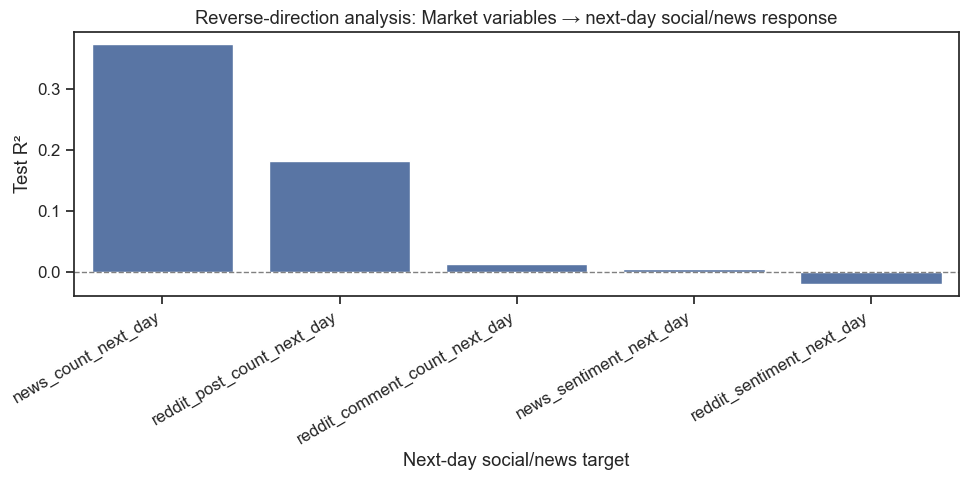

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=reverse_results_df,
    x="target",
    y="r2"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Reverse-direction analysis: Market variables → next-day social/news response")
plt.xlabel("Next-day social/news target")
plt.ylabel("Test R²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

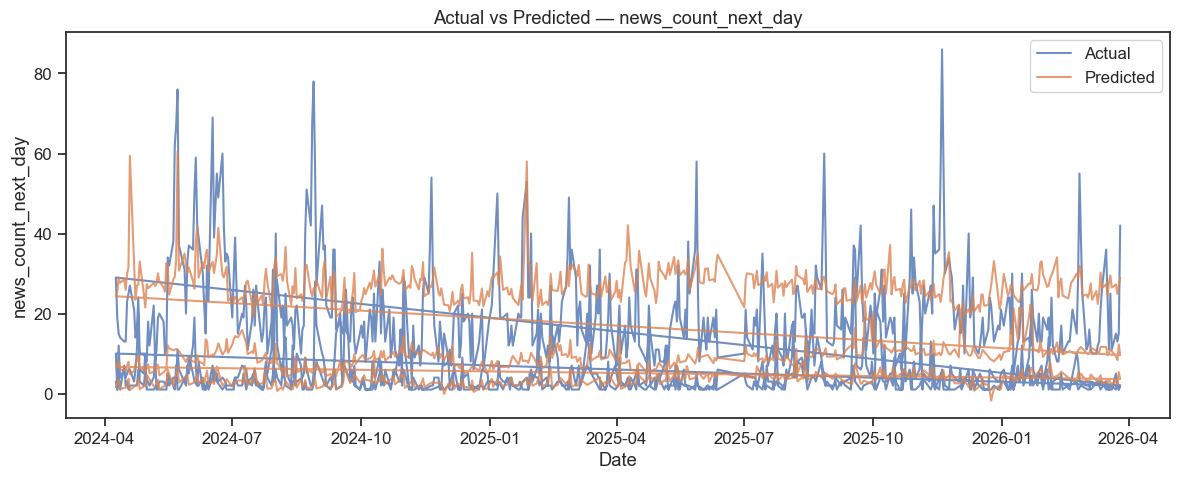

In [12]:
best_target = reverse_results_df.iloc[0]["target"]
best_pred_data = reverse_predictions[best_target]

actual_pred_df = pd.DataFrame({
    "date": best_pred_data["date"].values,
    "actual": best_pred_data["y_test"].values,
    "predicted": best_pred_data["y_pred"]
})

plt.figure(figsize=(12, 5))

plt.plot(
    actual_pred_df["date"],
    actual_pred_df["actual"],
    label="Actual",
    alpha=0.8
)

plt.plot(
    actual_pred_df["date"],
    actual_pred_df["predicted"],
    label="Predicted",
    alpha=0.8
)

plt.title(f"Actual vs Predicted — {best_target}")
plt.xlabel("Date")
plt.ylabel(best_target)
plt.legend()
plt.tight_layout()
plt.show()

*The reverse-direction analysis indicates that market variables are considerably
more informative for predicting future attention-related activity than future
sentiment. The strongest predictive performance was achieved for next-day news
coverage (R² = 0.374), followed by Reddit posting activity (R² = 0.182), while
both sentiment variables remained essentially unpredictable.*